# 04 — Volatility smile, skew et surface de volatilité

**Question.** Que nous apprend la structure de la volatilité implicite sur les anticipations du marché ? Est-elle stable selon les conditions de marché ?

Si Black-Scholes était vrai, toutes les options d'un même sous-jacent auraient **la même** volatilité implicite. On montre ici que ce n'est pas le cas : l'IV dépend fortement du strike (*smile/skew*) et de la maturité (*structure par terme*), et cette structure se déforme selon le régime de marché.

Conventions : on utilise les **options OTM** (puts pour $K<S$, calls pour $K \ge S$), les plus liquides, et le **forward implicite** du notebook 03. La log-moneyness forward est $k = \ln(K/F)$.

In [1]:
import sys, pathlib, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))
warnings.filterwarnings("ignore", category=RuntimeWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from plotting import set_style, savefig, save_table, PALETTE

set_style()
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
pd.set_option("display.width", 160)
%matplotlib inline
from mpl_toolkits.mplot3d import Axes3D  # noqa
from scipy.interpolate import griddata
from pipeline import load_chain_with_iv
from volatility_smile import plot_volatility_smile
from volatility_surface import build_volatility_surface, plot_volatility_surface_3d, plot_volatility_heatmap
from surface_tools import otm_slices, iv_at, term_structure
from plotting import FIG_DIR

REF_DATE = "2022-08-01"
df, raw, control = load_chain_with_iv(REF_DATE)
S0 = df.spot.iloc[0]
print(f"{REF_DATE} : spot = {S0:.2f} | {len(df):,} options | {(df.iv_status=='success').mean():.1%} d'IV valides")

2022-08-01 : spot = 410.72 | 8,427 options | 97.9% d'IV valides


## 1. Le smile d'une échéance (fonction `plot_volatility_smile` du projet)

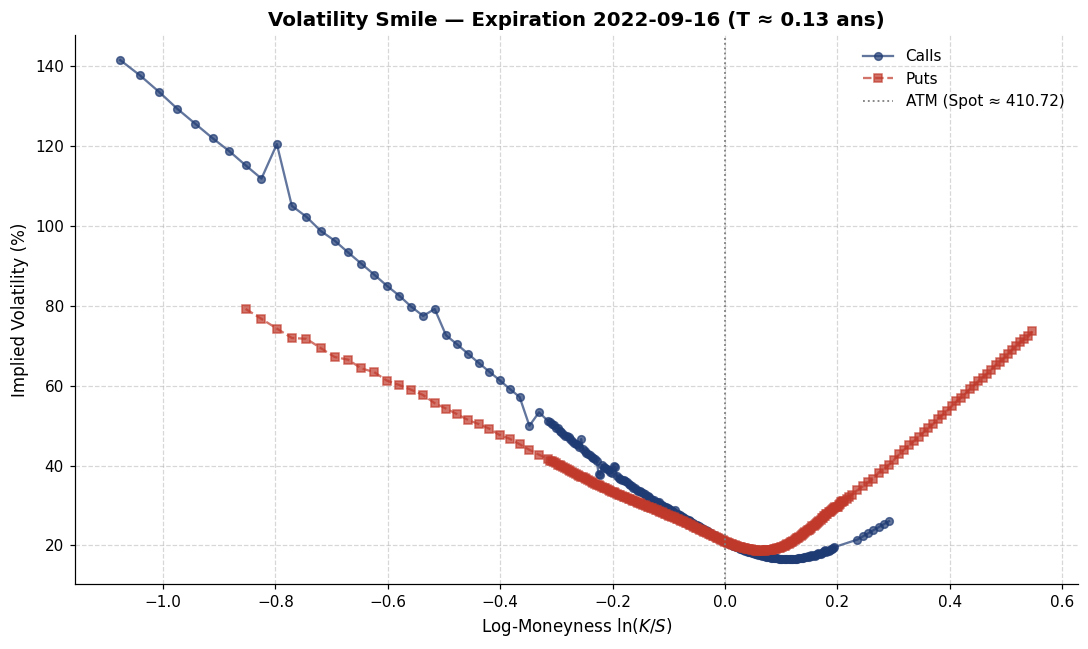

In [2]:
plot_volatility_smile(df, expiration="2022-09-16", use_moneyness=True, save_path=FIG_DIR / "04_smile_single_expiry.png")

## 2. Smiles OTM pour plusieurs maturités

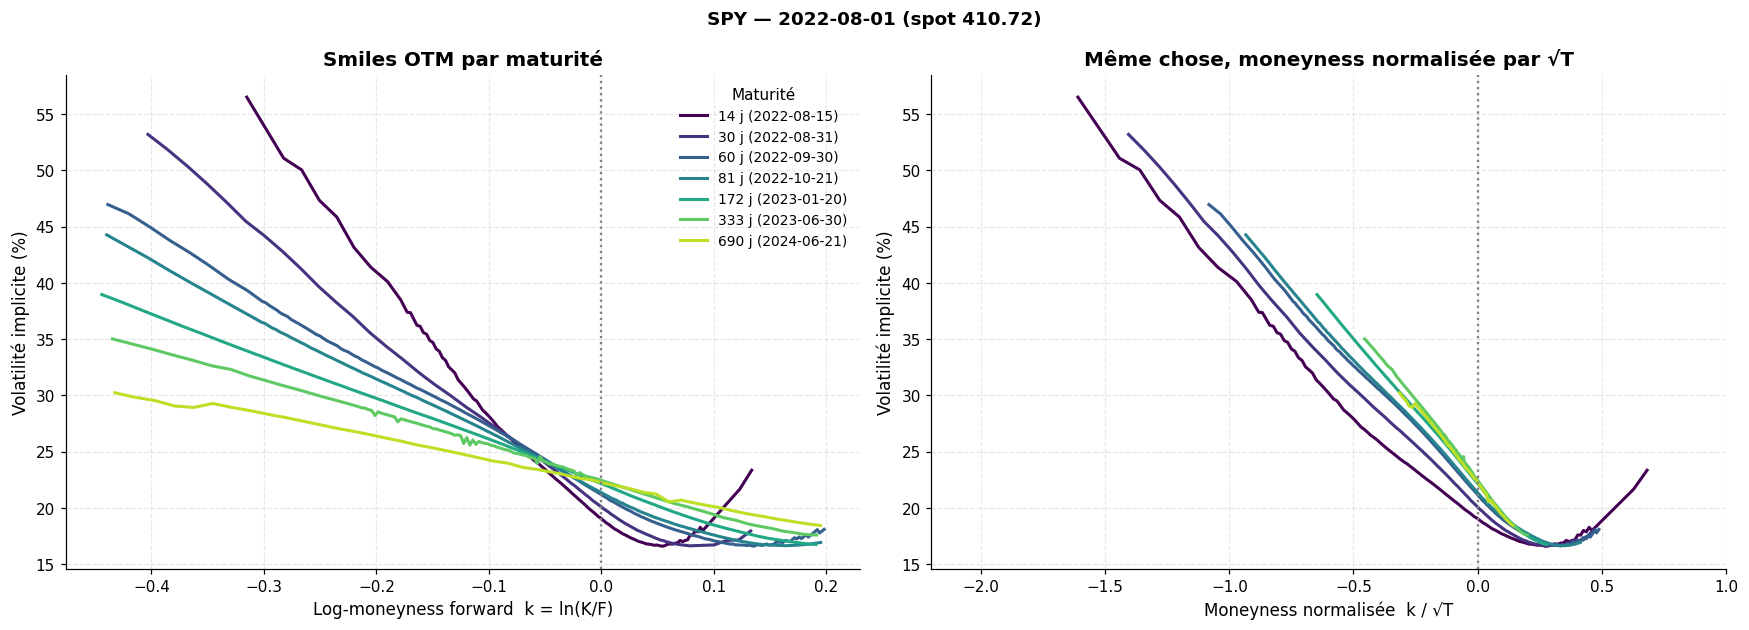

In [3]:
slices = otm_slices(df)
targets = [14, 30, 60, 90, 180, 365, 730]
Ts = np.array(sorted(slices))
chosen = sorted({Ts[np.argmin(np.abs(Ts - d / 365))] for d in targets})
cmap = plt.cm.viridis(np.linspace(0, 0.9, len(chosen)))

fig, axes = plt.subplots(1, 2, figsize=(16, 5.8))
for T, c in zip(chosen, cmap):
    g = slices[T]; g = g[g.k.between(-0.45, 0.2)]
    lab = f"{int(round(T*365))} j ({g.expiration.iloc[0].date()})"
    axes[0].plot(g.k, g.implied_vol * 100, "-", color=c, lw=2, label=lab)
    axes[1].plot(g.k / np.sqrt(T), g.implied_vol * 100, "-", color=c, lw=2, label=lab)
axes[0].set_xlabel("Log-moneyness forward  k = ln(K/F)"); axes[0].set_title("Smiles OTM par maturité")
axes[1].set_xlabel("Moneyness normalisée  k / √T"); axes[1].set_xlim(-2.2, 1.0); axes[1].set_title("Même chose, moneyness normalisée par √T")
for ax in axes:
    ax.axvline(0, color="grey", ls=":"); ax.set_ylabel("Volatilité implicite (%)")
axes[0].legend(title="Maturité", fontsize=9)
fig.suptitle(f"SPY — {REF_DATE} (spot {S0:.2f})", fontweight="bold")
fig.tight_layout(); savefig(fig, "04_smiles_multi_maturity.png"); plt.show()

**Lecture.**
- Ce n'est pas un « smile » symétrique mais un **skew** fortement négatif : l'IV des puts OTM (protection contre une baisse) est bien plus élevée que celle des calls OTM. À un mois, l'IV passe de ~17 % pour un call à 110 % du forward à ~37 % pour un put à 80 % (grille de la section 4).
- Le skew est **plus pentu à court terme** (panneau gauche). Une fois la moneyness normalisée par $\sqrt T$ (panneau droit), les courbes se regroupent beaucoup plus : l'essentiel de la dépendance en maturité est une question d'échelle de diffusion.
- Interprétation économique : les investisseurs paient une **prime d'assurance** sur les puts (demande structurelle de couverture sur les indices), et le marché price une distribution à **queue gauche épaisse** (krachs) et une **corrélation négative spot-vol** (effet de levier) — exactement ce que le paramètre $\rho<0$ de Heston cherchera à reproduire.
- Côté calls, l'IV remonte légèrement dans l'aile droite : c'est la petite partie « smile » (convexité, ou *volga premium*).

## 3. Structure par terme de l'IV ATM et du skew

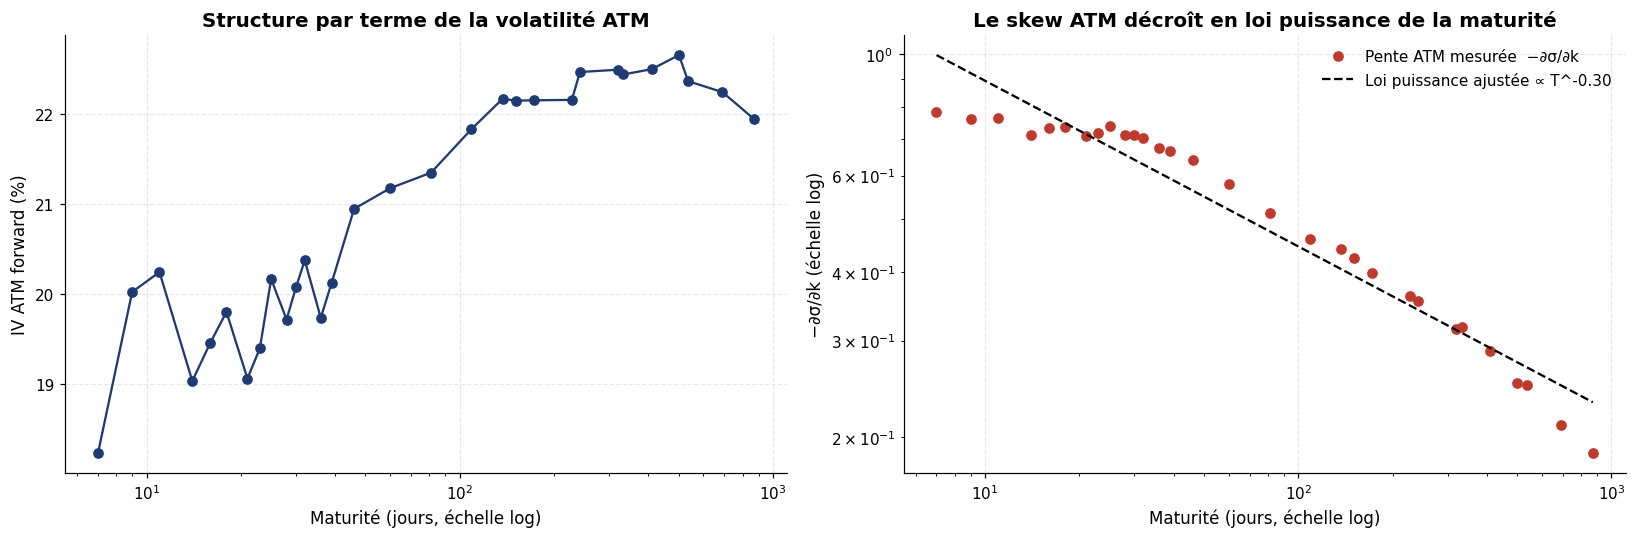

Exposant de décroissance du skew : -0.30  (valeurs empiriques usuelles sur indices : −0.3 à −0.5)


In [4]:
ts = term_structure(slices)
ts = ts[ts["T"] > 5 / 365]
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(ts["T"] * 365, ts.atm_iv * 100, "o-", color=PALETTE["navy"])
axes[0].set_xscale("log"); axes[0].set_xlabel("Maturité (jours, échelle log)"); axes[0].set_ylabel("IV ATM forward (%)")
axes[0].set_title("Structure par terme de la volatilité ATM")

m = ts.skew_slope.notna() & (ts.skew_slope < 0)
x, y = np.log(ts.loc[m, "T"]), np.log(-ts.loc[m, "skew_slope"])
alpha, c0 = np.polyfit(x, y, 1)
axes[1].loglog(ts.loc[m, "T"] * 365, -ts.loc[m, "skew_slope"], "o", color=PALETTE["crimson"], label="Pente ATM mesurée  −∂σ/∂k")
tt = np.linspace(ts.loc[m, "T"].min(), ts.loc[m, "T"].max(), 100)
axes[1].loglog(tt * 365, np.exp(c0) * tt**alpha, "--", color="k", label=f"Loi puissance ajustée ∝ T^{alpha:.2f}")
axes[1].set_xlabel("Maturité (jours, échelle log)"); axes[1].set_ylabel("−∂σ/∂k (échelle log)")
axes[1].set_title("Le skew ATM décroît en loi puissance de la maturité"); axes[1].legend()
fig.tight_layout(); savefig(fig, "04_term_structure_atm_skew.png"); plt.show()
print(f"Exposant de décroissance du skew : {alpha:.2f}  (valeurs empiriques usuelles sur indices : −0.3 à −0.5)")
save_table(ts.assign(T_jours=(ts["T"]*365).round()), "04_term_structure_ref_date")

- L'IV ATM est croissante avec la maturité le 1er août 2022 (~18 % à une semaine → ~22,5 % à un an) : le marché sort d'un rebond estival et price un retour vers une vol plus élevée.
- La pente du skew décroît comme $T^{\alpha}$ avec $\alpha \approx -0.30$ (fourchette empirique usuelle sur indices : −0,3 à −0,5). C'est un fait stylisé bien documenté des indices actions : un modèle à volatilité stochastique « diffusif » comme Heston produit un skew qui s'aplatit **trop lentement** aux maturités courtes (∝ constante quand $T\to0$ au lieu d'exploser) — on le vérifiera sur les erreurs de calibration (notebook 05).

## 4. La surface de volatilité implicite

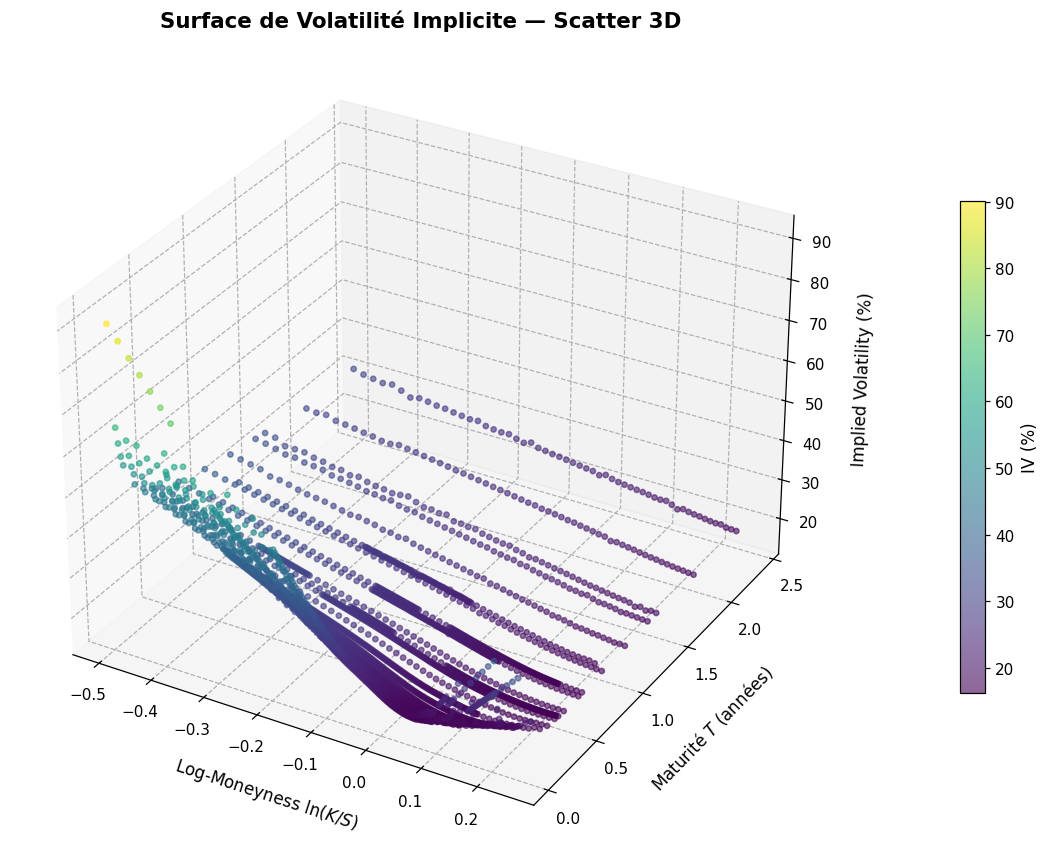

In [5]:
# Scatter 3D brut (fonctions build_volatility_surface / plot_volatility_surface_3d du projet), options OTM uniquement
surf_df = build_volatility_surface(df[df.is_otm & df["T"].between(0.02, 2.5) & df.log_moneyness.between(-0.5, 0.25)])
plot_volatility_surface_3d(surf_df, save_path=FIG_DIR / "04_surface_scatter3d.png")

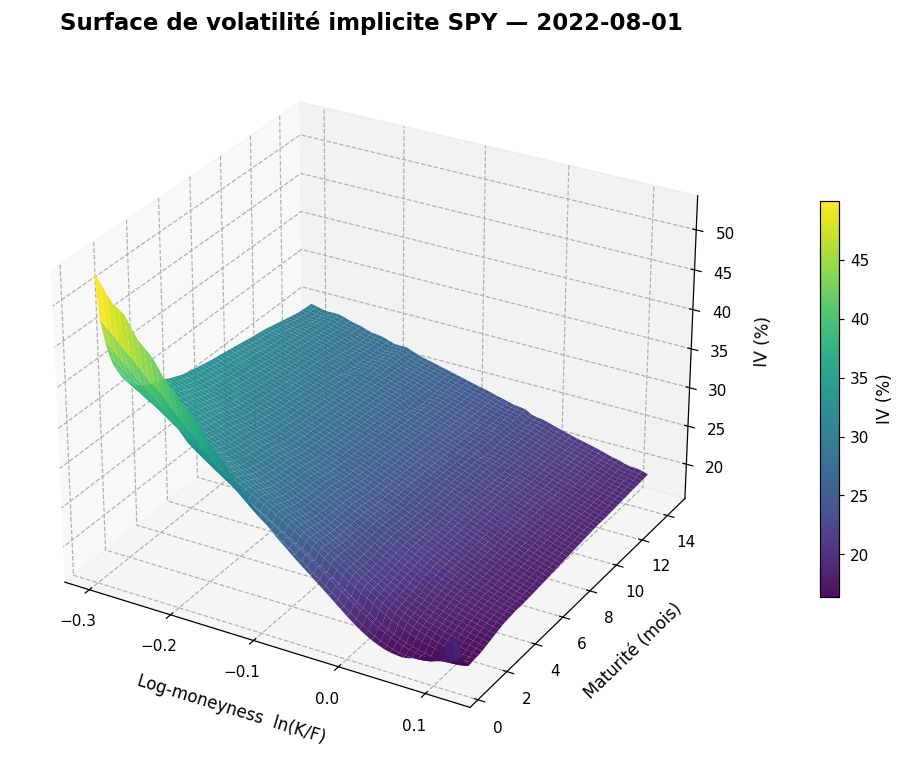

In [6]:
# Surface lissée : interpolation sur une grille régulière (k, T)
pts = pd.concat([g.assign(T=T) for T, g in slices.items() if 0.03 <= T <= 1.5])
pts = pts[pts.k.between(-0.35, 0.15)]
kk, tt = np.meshgrid(np.linspace(-0.3, 0.12, 60), np.linspace(0.04, 1.2, 60))
zz = griddata((pts.k, pts["T"]), pts.implied_vol * 100, (kk, tt), method="linear")

fig = plt.figure(figsize=(13, 8.5))
ax = fig.add_subplot(projection="3d")
surf = ax.plot_surface(kk, tt * 12, zz, cmap="viridis", edgecolor="none", alpha=0.95, rstride=1, cstride=1, antialiased=True)
ax.set_xlabel("Log-moneyness  ln(K/F)", labelpad=10); ax.set_ylabel("Maturité (mois)", labelpad=10); ax.set_zlabel("IV (%)", labelpad=8)
ax.set_title(f"Surface de volatilité implicite SPY — {REF_DATE}", fontsize=15, fontweight="bold")
ax.view_init(elev=28, azim=-60)
fig.colorbar(surf, ax=ax, shrink=0.55, pad=0.08, label="IV (%)")
savefig(fig, "04_surface_smooth3d.png"); plt.show()

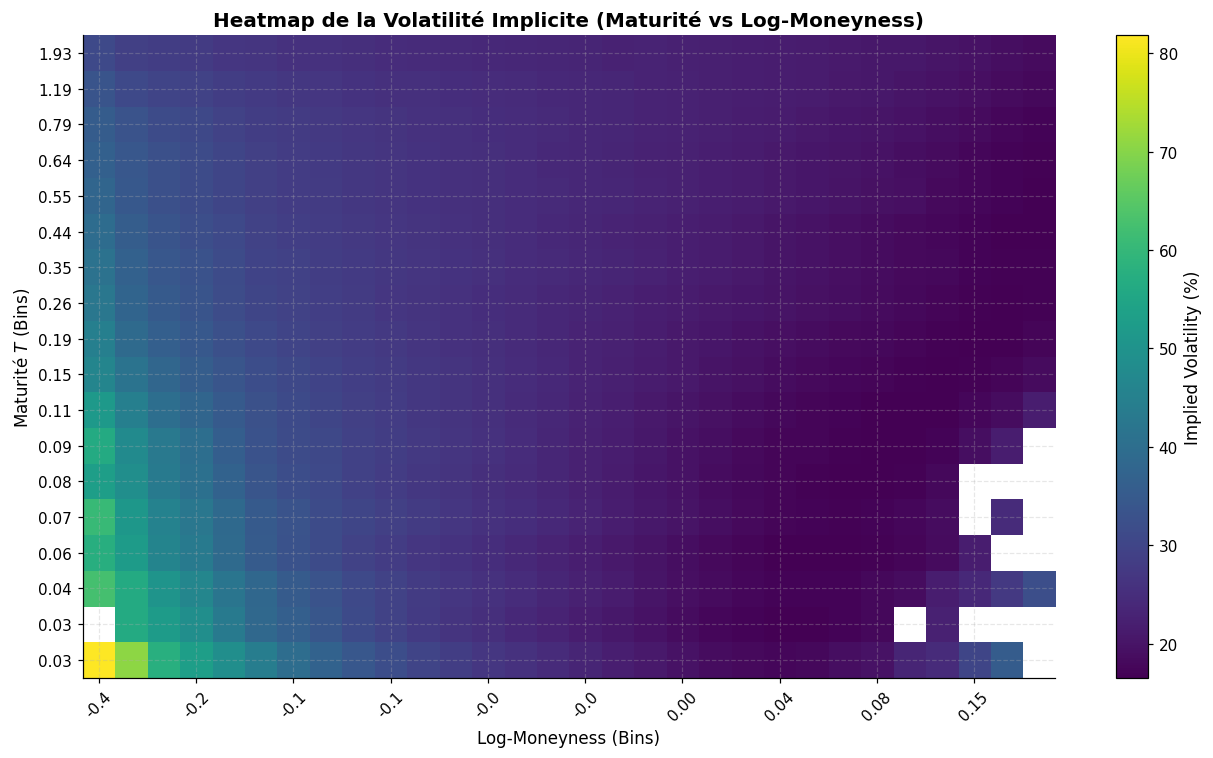

In [7]:
# Heatmap brute (fonction plot_volatility_heatmap du projet, bins par quantiles)
plot_volatility_heatmap(surf_df, save_path=FIG_DIR / "04_heatmap_quantile_bins.png")

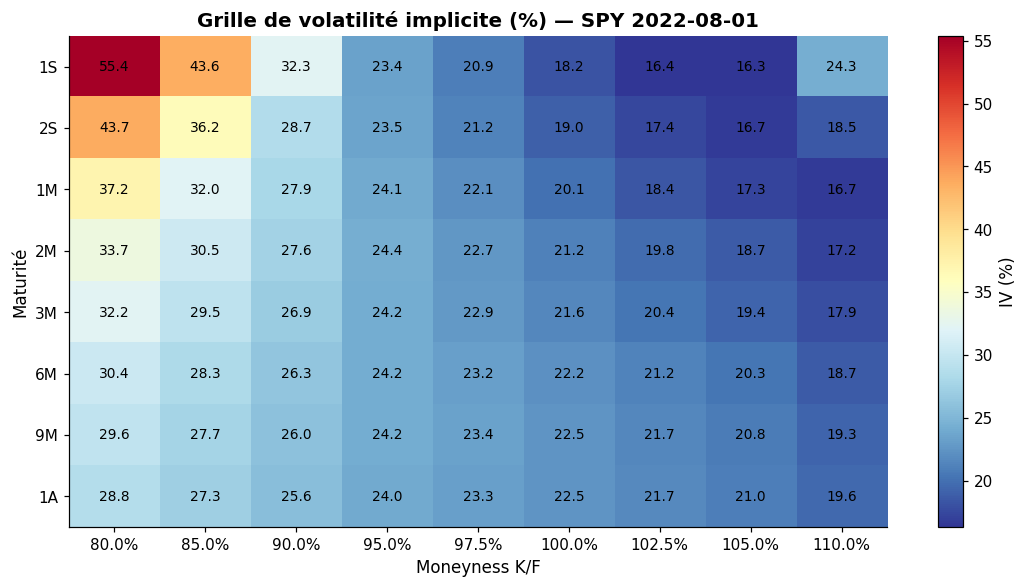

In [8]:
# Heatmap "desk" : grille fixe moneyness K/F × maturité, valeurs interpolées et annotées
mny = [0.80, 0.85, 0.90, 0.95, 0.975, 1.00, 1.025, 1.05, 1.10]
mats = {"1S": 7, "2S": 14, "1M": 30, "2M": 61, "3M": 91, "6M": 182, "9M": 273, "1A": 365}
grid = pd.DataFrame([[iv_at(slices, np.log(m), d / 365) * 100 for m in mny] for d in mats.values()],
                    index=mats.keys(), columns=[f"{m:.1%}" for m in mny])
fig, ax = plt.subplots(figsize=(12, 5.8))
im = ax.imshow(grid.values, cmap="RdYlBu_r", aspect="auto")
for i in range(grid.shape[0]):
    for j in range(grid.shape[1]):
        v = grid.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=9, color="k")
ax.set_xticks(range(len(mny)), grid.columns); ax.set_yticks(range(len(mats)), grid.index)
ax.set_xlabel("Moneyness K/F"); ax.set_ylabel("Maturité"); ax.grid(False)
ax.set_title(f"Grille de volatilité implicite (%) — SPY {REF_DATE}")
fig.colorbar(im, ax=ax, label="IV (%)"); savefig(fig, "04_heatmap_grid.png"); plt.show()
save_table(grid.reset_index(names="Maturité"), "04_iv_grid_ref_date", floatfmt=".1f")

La grille se lit comme un écran de desk : chaque ligne est un smile, chaque colonne une structure par terme à moneyness constante. On retrouve le skew (IV élevée à gauche, surtout à court terme) et une structure par terme ATM peu pentue.

## 5. La surface change-t-elle avec le régime de marché ?

Quatre dates représentatives de 2022 :

| Régime | Date | Contexte |
|---|---|---|
| **Calme** | 03/01/2022 | Plus haut historique de SPY (477,8), vol réalisée faible |
| **Stress** | 16/06/2022 | Lendemain de la hausse de 75 pb de la Fed, SPY −23 % depuis janvier |
| **Rebond** | 16/08/2022 | Sommet du rallye estival (+17 % depuis juin) |
| **Sell-off** | 12/10/2022 | Plus bas annuel (356,6), CPI élevé, vol réalisée ~24 % |

In [9]:
REGIMES = {"Calme (03/01)": "2022-01-03", "Stress (16/06)": "2022-06-16", "Rebond (16/08)": "2022-08-16", "Sell-off (12/10)": "2022-10-12"}
REG_COL = dict(zip(REGIMES, [PALETTE["teal"], PALETTE["crimson"], PALETTE["sky"], PALETTE["purple"]]))
reg_slices, reg_rows = {}, []
for name, d in REGIMES.items():
    dfr, _, _ = load_chain_with_iv(d)
    sl = otm_slices(dfr); reg_slices[name] = sl
    atm1 = iv_at(sl, 0.0, 30 / 365); atm6 = iv_at(sl, 0.0, 182 / 365)
    p90 = iv_at(sl, np.log(0.90), 30 / 365); c105 = iv_at(sl, np.log(1.05), 30 / 365)
    reg_rows.append({"Régime": name, "Spot": dfr.spot.iloc[0], "IV ATM 1M (%)": 100 * atm1, "IV ATM 6M (%)": 100 * atm6,
                     "Pente terme 6M−1M (pts)": 100 * (atm6 - atm1), "Skew 1M : IV90% − IV100% (pts)": 100 * (p90 - atm1),
                     "Skew 1M : IV90% − IV105% (pts)": 100 * (p90 - c105)})
regimes_tab = pd.DataFrame(reg_rows)
save_table(regimes_tab, "04_regimes_summary", floatfmt=".2f")
regimes_tab

,Régime,Spot,IV ATM 1M (%),IV ATM 6M (%),Pente terme 6M−1M (pts),Skew 1M : IV90% − IV100% (pts),Skew 1M : IV90% − IV105% (pts)
0,Calme (03/01),477.7700,12.3219,17.8216,5.4996,11.6928,14.0613
1,Stress (16/06),366.8900,29.3467,26.9051,-2.4416,7.6928,10.7102
2,Rebond (16/08),429.6900,17.6216,20.9163,3.2947,7.7284,10.3025
3,Sell-off (12/10),356.5800,30.9830,27.0955,-3.8876,5.1031,7.5021


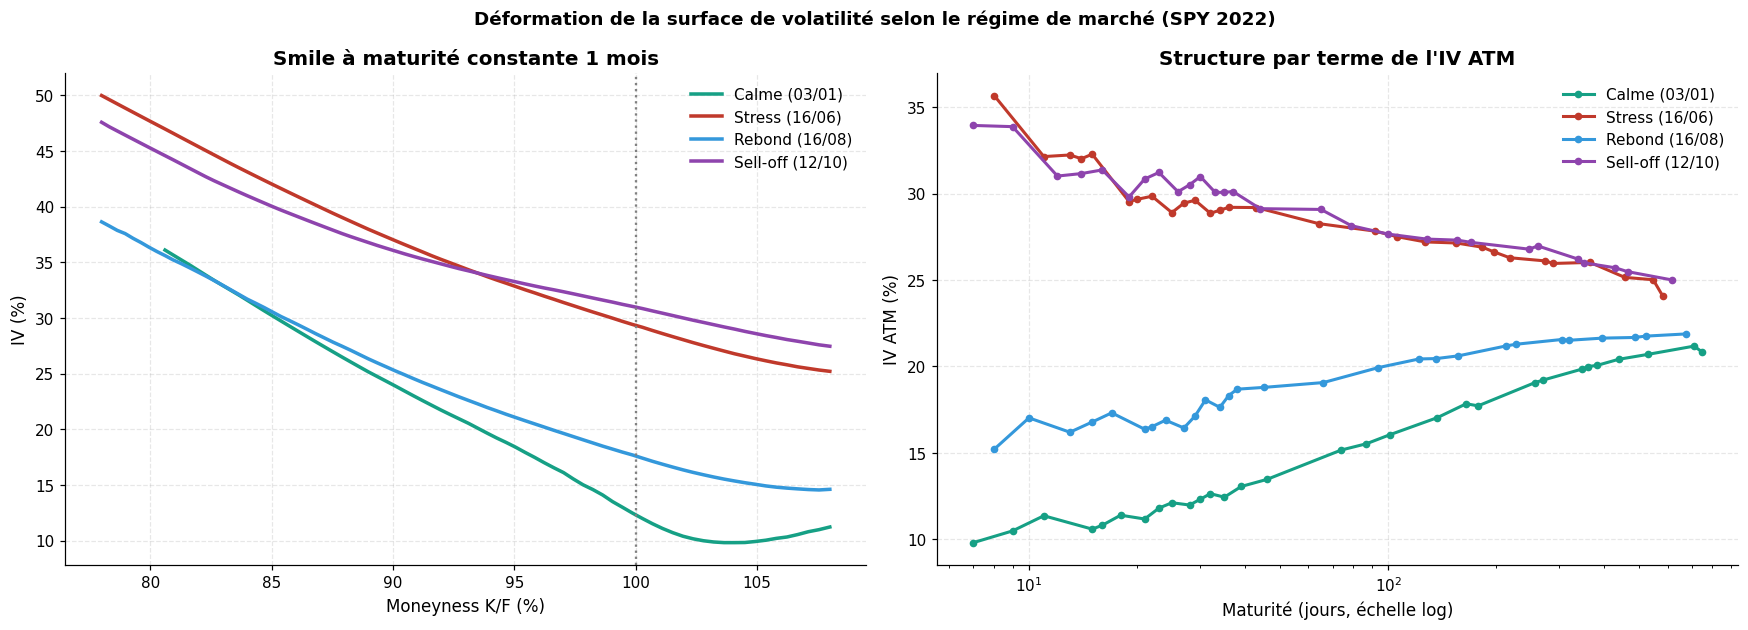

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.8))
kgrid = np.linspace(np.log(0.78), np.log(1.08), 80)
for name, sl in reg_slices.items():
    ivs = [iv_at(sl, k, 30 / 365) * 100 for k in kgrid]
    axes[0].plot(np.exp(kgrid) * 100, ivs, lw=2.3, color=REG_COL[name], label=name)
    tsr = term_structure(sl); tsr = tsr[tsr["T"].between(7 / 365, 2.1)]
    axes[1].plot(tsr["T"] * 365, tsr.atm_iv * 100, "o-", ms=4, lw=2, color=REG_COL[name], label=name)
axes[0].set_xlabel("Moneyness K/F (%)"); axes[0].set_ylabel("IV (%)"); axes[0].set_title("Smile à maturité constante 1 mois")
axes[0].axvline(100, color="grey", ls=":"); axes[0].legend()
axes[1].set_xscale("log"); axes[1].set_xlabel("Maturité (jours, échelle log)"); axes[1].set_ylabel("IV ATM (%)")
axes[1].set_title("Structure par terme de l'IV ATM"); axes[1].legend()
fig.suptitle("Déformation de la surface de volatilité selon le régime de marché (SPY 2022)", fontweight="bold")
fig.tight_layout(); savefig(fig, "04_regimes_smile_termstructure.png"); plt.show()

## Conclusions

1. **Black-Scholes est rejeté par les prix de marché** : l'IV varie de plus de 20 points entre strikes pour une même maturité. Le smile d'indice est un **skew** négatif, reflet de la demande de protection et d'une corrélation spot-volatilité négative.
2. **Structure par terme du skew** : la pente ATM décroît en loi puissance de $T$ ; le skew court terme est très prononcé.
3. **Régimes** (voir tableau et graphique) :
   - En **régime calme** (03/01), la vol ATM 1 mois n'est que de **12,3 %** et la structure par terme est fortement **croissante** (contango de +5,5 pts entre 1 et 6 mois) : le marché anticipe un retour vers une vol moyenne plus élevée.
   - En **stress** (16/06) et **sell-off** (12/10), le niveau monte à **29–31 %** et la structure par terme s'**inverse** (backwardation de −2,4 et −3,9 pts) : la vol court terme dépasse la vol long terme car le marché anticipe un retour à la moyenne de la volatilité — c'est exactement le rôle du paramètre $\kappa$ de Heston.
   - Contre-intuitif mais classique : le **skew en points de vol est le plus pentu en marché calme** (IV 90 % − IV 100 % = **11,7 pts** le 03/01) et le plus plat au plus bas du marché (**5,1 pts** le 12/10). Au sommet, la protection est bon marché et très demandée ; après la baisse, la vol ATM a déjà absorbé le choc et les puts OTM « rattrapent » moins. En relatif (skew / niveau ATM), l'écart est encore plus marqué (×0,95 vs ×0,16).
4. Ces déformations motivent un **modèle à volatilité stochastique** dont les paramètres ($v_0$, $\theta$, $\kappa$, $\xi$, $\rho$) ont une interprétation directe en termes de niveau, structure par terme et skew : c'est l'objet du notebook 05.